In [1]:
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

from nltk.metrics.distance import edit_distance
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, T5ForConditionalGeneration

2026-05-06 18:31:49.959075: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-06 18:31:49.984520: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 18:31:51.358072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-06 18:31:54.324350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
def loadData():
    df = pd.read_csv("filtered_dataset.csv")

    df = df.sample(frac=1, random_state=27)
    df.reset_index(inplace=True)
    df.pop("index")

    df = df[["romanized", "devanagari"]]
    df.columns = ["input", "label"]
    train_df = df[:-200]
    val_df = df[-200:]

    mask = train_df.input.str.len() > 300
    val_df = pd.concat([val_df, train_df[mask]], ignore_index=True)
    train_df = train_df[~mask]

    return train_df, val_df

In [4]:
train_df, val_df = loadData()

FileNotFoundError: [Errno 2] No such file or directory: 'filtered_dataset.csv'

In [5]:
print(len(train_df), len(val_df))
print(train_df.head())

NameError: name 'train_df' is not defined

In [3]:
class MyDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return row.input, row.label
    
class DataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch: List[Tuple[str, str]]) -> Dict[str, torch.Tensor]:
        inputs = [input for input, _ in batch]
        labels = [label for _, label in batch]
        encodings = self.tokenizer(inputs, padding="longest", return_tensors="pt")
        label_encodings = self.tokenizer(labels, padding="longest", return_tensors="pt")

        input_ids = encodings.input_ids
        attention_mask = encodings.attention_mask
        labels = label_encodings.input_ids
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [4]:
device = torch.device("cpu")

def model_init(checkpoint):
    model = T5ForConditionalGeneration.from_pretrained(checkpoint)
    return model.to(device)

def dict_to_cuda(batch):
    return {k: v.to(device) for k, v in batch.items()}

In [5]:
@torch.no_grad()
def eval_model(model, val_loader, tokenizer):
    model.eval()
    total = 0
    count = 0
    stream = tqdm(val_loader)
    for batch in stream:
        batch = dict_to_cuda(batch)
        loss = model(**batch).loss
        total += loss.item()
        count += 1
        stream.set_description_str(desc=f"val_edit_dist {total / count:.3f}")

    model.train()
    return total / count

In [6]:
checkpoint = "google/byt5-small"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = model_init(checkpoint)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
train_ds = MyDataset(train_df)
val_ds = MyDataset(val_df)
data_collator = DataCollator(tokenizer)
train_loader = DataLoader(train_ds, batch_size=2, collate_fn=data_collator)
val_loader = DataLoader(val_ds, batch_size=8, collate_fn=data_collator)

NameError: name 'train_df' is not defined

In [39]:
max_epochs = 10
best = float("inf")
trigger = 0

for epoch in range(max_epochs):
    stream = tqdm(train_loader)
    total = 0
    count = 0
    for batch in stream:
        batch = dict_to_cuda(batch)
        loss = model(**batch).loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
        count += 1
        stream.set_description_str(
            f"Epoch {epoch}/{max_epochs} | Loss {total / count : .3f}"
        )
    loss = total / count
    eval_metric = eval_model(model, val_loader, tokenizer)
    print(
        f"Epoch {epoch}/{max_epochs} | Loss {loss: .3f} | Val Loss {eval_metric: .4f}"
    )

    trigger += 1

    if eval_metric < best:
        to_save = {"model": model.state_dict(), "optimizer": optimizer}
        best = eval_metric
        trigger = 0
        torch.save(to_save, "fine_tuned_byt5.pt")

    if trigger > 5:
        break

Epoch 0/10 | Loss  0.362: 100%|██████████| 1182/1182 [01:49<00:00, 10.84it/s]
val_edit_dist 0.186: 100%|██████████| 26/26 [00:02<00:00, 12.94it/s]


Epoch 0/10 | Loss  0.362 | Val Loss  0.1862


Epoch 1/10 | Loss  0.351: 100%|██████████| 1182/1182 [01:53<00:00, 10.42it/s]
val_edit_dist 0.193: 100%|██████████| 26/26 [00:02<00:00, 12.41it/s]


Epoch 1/10 | Loss  0.351 | Val Loss  0.1930


Epoch 2/10 | Loss  0.233: 100%|██████████| 1182/1182 [01:53<00:00, 10.39it/s]
val_edit_dist 0.181: 100%|██████████| 26/26 [00:02<00:00, 12.49it/s]


...

Epoch 7/10 | Loss  0.124 | Val Loss  0.1675


Epoch 8/10 | Loss  0.115: 100%|██████████| 1182/1182 [01:55<00:00, 10.25it/s]
val_edit_dist 0.171: 100%|██████████| 26/26 [00:02<00:00, 12.43it/s]


Epoch 8/10 | Loss  0.115 | Val Loss  0.1707


Epoch 9/10 | Loss  0.107: 100%|██████████| 1182/1182 [01:54<00:00, 10.35it/s]
val_edit_dist 0.169: 100%|██████████| 26/26 [00:02<00:00, 12.41it/s]

Epoch 9/10 | Loss  0.107 | Val Loss  0.1688


In [15]:
def batch_edit_distance(alist, blist):
    distances = [edit_distance(a, b) for a, b in zip(alist, blist)]
    return sum(distances), len(distances)

@torch.no_grad()
def eval_model_edit_distance(model, val_loader, tokenizer):
    model.eval()
    total = 0
    count = 0
    stream = tqdm(val_loader)
    for batch in stream:
        batch = dict_to_cuda(batch)
        outputs = model.generate(batch['input_ids'], max_length=1024)
        outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        labels = batch['labels']
        labels[labels == -100] = 0
        targets = tokenizer.batch_decode(labels, skip_special_tokens=True)
        s, l = batch_edit_distance(outputs, targets)
        total += s
        count += l
        stream.set_description_str(desc=f'val_edit_dist {total / count:.4f}')
        
    model.train()
    return total / count

In [ ]:
model.load_state_dict(torch.load('../../claridenfinalmodels/augmented_dataset/augmented_dataset_byT5_epoch_8.pt',weights_only=False, map_location=torch.device('cpu')))
model.to(device)
model.eval()

def transliterate(sentence: str, max_length: int = 128):
    
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    
    
    outputs = model.generate(
        input_ids=inputs.input_ids, 
        attention_mask=inputs.attention_mask,
        max_length=max_length,
        num_beams=5,          
        early_stopping=True
    )
    
    
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded


romanized_sentence = "aja jasari pani kam sakauna parcha"
devanagari_sentence = transliterate(romanized_sentence)
print(devanagari_sentence)


In [18]:
import torch
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein

# --- Load your model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('fine_tuned_byt5.pt', weights_only=False)['model'])
model.to(device)
model.eval()

# --- Transliteration function ---
def transliterate(sentence: str, max_length: int = 128):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_length=max_length,
        num_beams=5,
        early_stopping=True
    )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded

# --- Evaluation function ---
def evaluate(df_val):
    total_chars = 0
    total_char_errors = 0
    total_words = 0
    total_word_correct = 0
    bleu_scores = []

    smooth = SmoothingFunction().method1

    for idx, row in df_val.iterrows():
        pred = transliterate(row['input'])
        true = row['label']

        # --- Character Error Rate (CER) ---
        char_errors = Levenshtein.distance(pred, true)
        total_char_errors += char_errors
        total_chars += len(true)

        # --- Word Accuracy ---
        pred_words = pred.split()
        true_words = true.split()
        total_words += len(true_words)
        # Count exact word matches
        correct_words = sum(p==t for p,t in zip(pred_words,true_words))
        total_word_correct += correct_words

        # --- BLEU-4 (character level) ---
        # split characters for BLEU
        pred_chars = list(pred)
        true_chars = list(true)
        bleu = sentence_bleu([true_chars], pred_chars, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
        bleu_scores.append(bleu)

    cer = total_char_errors / total_chars
    word_accuracy = total_word_correct / total_words
    avg_bleu4 = sum(bleu_scores) / len(bleu_scores)

    print(f"CER: {cer:.4f}")
    print(f"Word Accuracy: {word_accuracy:.4f}")
    print(f"Average BLEU-4: {avg_bleu4:.4f}")

    return cer, word_accuracy, avg_bleu4

# --- Example usage ---
train_df, val_df = loadData()
evaluate(val_df)


CER: 0.5280
Word Accuracy: 0.2876
Average BLEU-4: 0.4996


(0.5279889879391715, 0.28758401131941985, 0.4995692453834325)

In [21]:
import random

def print_validation_samples(df_val, num_samples=30):
    num_samples = min(num_samples, len(df_val))
    sampled_indices = random.sample(range(len(df_val)), num_samples)

    print(f"{'Input (Romanized)':<50} | {'Expected (Devanagari)':<50} | {'Predicted (Devanagari)'}")
    print("-"*150)

    for idx in sampled_indices:
        row = df_val.iloc[idx]
        input_text = row['input']
        expected = row['label']
        predicted = transliterate(input_text)
        print(f"{input_text:<50} | {expected:<50} | {predicted}")

# Example usage:
print_validation_samples(val_df, num_samples=30)


Input (Romanized)                                  | Expected (Devanagari)                              | Predicted (Devanagari)
------------------------------------------------------------------------------------------------------------------------------------------------------
abaa maile panii fewa tall katera basti baslna parla | अब मले पनि फेवा टल काटेर बस्ती बस्ना पार्ला        | अब मैले पनि फेवा टाल कटेरा बस्ती बस्न पर्छ
everythink views ko lagi jepni banidine            | एभ्रिथिङ्ग भ्यूज को लागि जेपनि बनिदिने             | एवरीथिंक भ्यूजको लागि जेप्नी बनिदिने
hamro ma para purbakal ma hamro baje haru le kaso nikaleko aahile pani thau dekhna sakinxha thulo chattan aahile herna sakinxha tara teha chanda sakinna tesma adhyan garna paya aru pani miltheyo ki  not a joke really ho | हाम्रो मा परा पुराकाल मा हाम्रो बaje हरू ले कसो निकालेको अहिले पनि थाउ देख्न सकिन्छ थुलो चट्टान अहिले हेर्न सकिन्छ तर त्यहाँ चन्दा सकिन्न त्यसमा अध्ययन गर्न पाया अरू पनि मिल्थेयो कि नट अ जोक रियली हो | हा

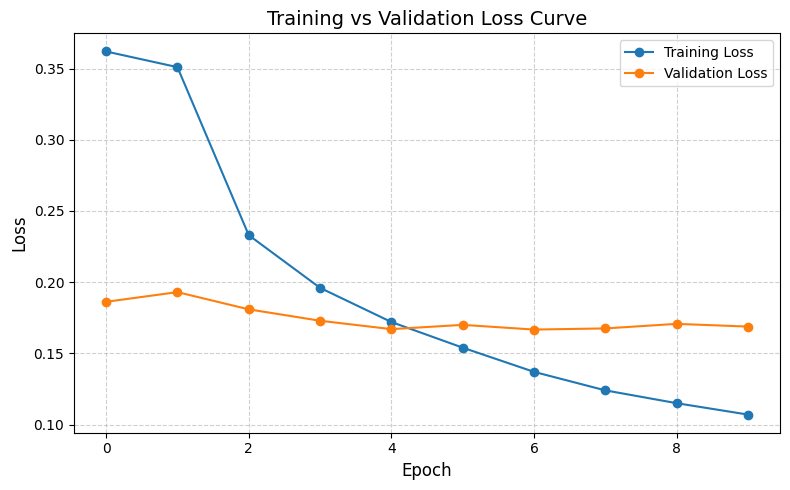

In [22]:
import re
import matplotlib.pyplot as plt

# Raw training log (exactly as you provided)
log_text = """
Epoch 0/10 | Loss  0.362 | Val Loss  0.1862
Epoch 1/10 | Loss  0.351 | Val Loss  0.1930
Epoch 2/10 | Loss  0.233 | Val Loss  0.1809
Epoch 3/10 | Loss  0.196 | Val Loss  0.1729
Epoch 4/10 | Loss  0.172 | Val Loss  0.1670
Epoch 5/10 | Loss  0.154 | Val Loss  0.1700
Epoch 6/10 | Loss  0.137 | Val Loss  0.1667
Epoch 7/10 | Loss  0.124 | Val Loss  0.1675
Epoch 8/10 | Loss  0.115 | Val Loss  0.1707
Epoch 9/10 | Loss  0.107 | Val Loss  0.1688
"""

# Extract epoch, train loss, and val loss using regex
epochs = [int(e) for e in re.findall(r'Epoch (\d+)', log_text)]
train_loss = [float(l) for l in re.findall(r'Loss\s+([\d.]+)\s*\| Val', log_text)]
val_loss = [float(v) for v in re.findall(r'Val Loss\s+([\d.]+)', log_text)]

# Plot the losses
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
import gradio as gr
from transformers import AutoTokenizer, T5ForConditionalGeneration
from huggingface_hub import hf_hub_download
import os
import re

torch.set_num_threads(1)
device = torch.device("cpu")
hf_token = os.getenv("HF_TOKEN")

with open("refined_english_words.txt", "r", encoding="utf-8") as f:
    english_words = set(word.strip().lower() for word in f.readlines())

byt5_checkpoint = "google/byt5-small"
byt5_tokenizer = AutoTokenizer.from_pretrained(byt5_checkpoint)
byt5_model = T5ForConditionalGeneration.from_pretrained(byt5_checkpoint).to(device)

byt5_model_path = hf_hub_download(
    repo_id="Sagar32/romanizedtransliterationmodel",
    filename="augmented_dataset_placeholder_byT5_epoch_8.pt",
    token=hf_token
)
byt5_state = torch.load(byt5_model_path, map_location="cpu")
byt5_model.load_state_dict(byt5_state, strict=False)
byt5_model.eval()



def mask_english(sentence):
    """
    1. Strip any existing '#' from input.
    2. Replace each English word with a single '#'.
    3. Return masked sentence and ordered list of English words (preserving position order).
    """

    sentence = sentence.replace("#", "").strip()

    tokens = re.findall(r"\w+|[^\w\s]", sentence, re.UNICODE)

    english_words_ordered = []  
    masked_tokens = []

    for tok in tokens:
        if tok.lower() in english_words:
            english_words_ordered.append(tok)  
            masked_tokens.append("#")       
        else:
            masked_tokens.append(tok)

    masked_sentence = " ".join(masked_tokens)
    return masked_sentence, english_words_ordered


def restore_english(transliterated_sentence, english_words_ordered):

    restored_tokens = transliterated_sentence.split()
    english_queue = list(english_words_ordered)  

    result_tokens = []
    for tok in restored_tokens:
        if tok == "#" and english_queue:
            result_tokens.append(english_queue.pop(0))  
        else:
            result_tokens.append(tok)

    if english_queue:
        result_tokens.extend(english_queue)

    return " ".join(result_tokens)


def transliterate(sentence):
    if not sentence.strip():
        return "Please enter text."

    masked_sentence, english_words_ordered = mask_english(sentence)

    inputs = byt5_tokenizer(
        masked_sentence,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(device)

    with torch.inference_mode():
        outputs = byt5_model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_length=256,
            num_beams=2,
            early_stopping=True
        )

    decoded = byt5_tokenizer.decode(outputs[0], skip_special_tokens=True)

    final = restore_english(decoded, english_words_ordered)
    return final


with gr.Blocks() as demo:
    gr.Markdown("## Nepali Romanized → Devanagari Transliterator")
    gr.Markdown("Powered by fine-tuned **ByT5** model ")

    input_text = gr.Textbox(
        lines=2,
        placeholder="Enter Romanized Nepali sentence..."
    )
    output_text = gr.Textbox(label="Devanagari Transliteration")

    submit_btn = gr.Button("Transliterate")
    submit_btn.click(
        transliterate,
        inputs=input_text,
        outputs=output_text
    )

demo.launch()